In [1]:
import matplotlib.pylab as plt 
%matplotlib inline
import numpy as np
import rubin_sim.splat as splat
import pandas as pd
import sqlite3
import healpy as hp
import copy
import datetime
import os

from rubin_sim.splat.plots import bright_filter_colors

from rubin_scheduler.utils import (
    angular_separation,
    ddf_locations,hpid2_ra_dec)

from rubin_sim.data import get_baseline
from os.path import basename

In [2]:
# Read in the current baseline simulation
db_file = "sp2_v5.4.0b_1yrs.db"
data_source = basename(db_file).replace('.db', '')
con = sqlite3.connect(db_file)
df = pd.read_sql('select * from observations;', con)
con.close()
# Convert to a numpy array
visits_array = df.to_records(index=False)


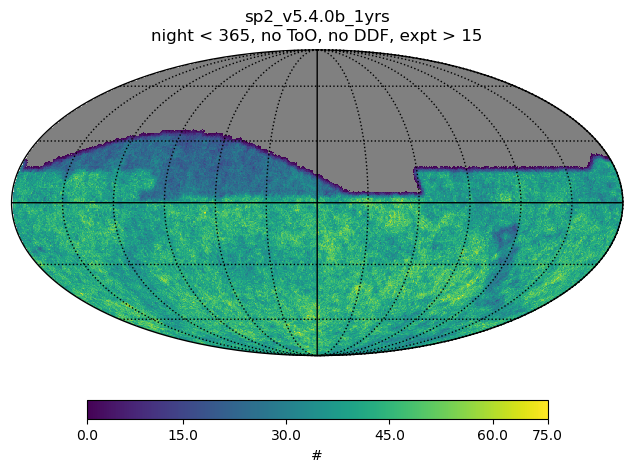

In [3]:
#fig_saver = splat.FigSaver(close_figs=False)
# If we want to use some automated label generation 
is_too = np.array(["ToO" in note for note in visits_array["scheduler_note"]])
is_ddf = np.array(["DD" in note for note in visits_array["scheduler_note"]])
info = {"data_source": data_source}
night_limit = 365
sub_data = visits_array[np.where( (visits_array["night"] < night_limit) &
                                  (~is_too) & 
                                  (visits_array["visitExposureTime"] > 15) &
                                (~is_ddf))]
info['observations_subset'] = "night < %i, no ToO, no DDF, expt > 15" % (night_limit)
sl = splat.Slicer()
metric = splat.CountMetric()
# Run the metics through the slicer
hp_array, info = sl(sub_data, metric, info=info)
pm = splat.PlotMoll(info=info)
fig = pm(hp_array)
# To save a fig
#fig_saver(fig, info)
# Compute a summary stat
summary_row = splat.gen_summary_row(info, "median", np.nanmedian(hp_array))
